In [5]:
import pandas as pd, numpy as np, json
from pathlib import Path

RAW = "../data/UFC_full_data_golden.csv"
RATINGS_PATH = "../models/elo_ratings.json"

# --- column names in your file ---
COL_RED  = "f_1_name"
COL_BLUE = "f_2_name"
COL_WIN  = "winner"
COL_DATE = "event_date"   # change ONLY if your date column is named differently

# 1) load and basic clean
df = pd.read_csv(RAW)
df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors="coerce")
df = df.dropna(subset=[COL_DATE, COL_RED, COL_BLUE, COL_WIN]).sort_values(COL_DATE).reset_index(drop=True)

print("Rows after basic clean:", len(df))

# 2) winner -> label: 1 if Red wins, 0 if Blue wins; skip draws/unknowns
def label_red_win(row):
    w = str(row[COL_WIN]).strip().lower()
    r = str(row[COL_RED]).strip().lower()
    b = str(row[COL_BLUE]).strip().lower()
    if w == r or w == "red":  return 1
    if w == b or w == "blue": return 0
    return np.nan

df["y"] = df.apply(label_red_win, axis=1).astype("float")
df = df.dropna(subset=["y"]).copy()
df["y"] = df["y"].astype(int)
print("Rows with clear winner label:", len(df))

# 3) candidate feature pairs (only create if both columns exist)
pairs = {
    "reach_diff":  ("f_1_fighter_reach_cm",  "f_2_fighter_reach_cm"),
    "height_diff": ("f_1_fighter_height_cm", "f_2_fighter_height_cm"),
    "age_diff":    ("f_1_fighter_age",       "f_2_fighter_age"),
    "weight_diff": ("f_1_fighter_weight_lbs","f_2_fighter_weight_lbs"),
}

for newcol, (c1, c2) in pairs.items():
    if c1 in df.columns and c2 in df.columns:
        df[newcol] = df[c1].astype(float) - df[c2].astype(float)

# 4) add Elo diff from your ratings file
BASE = 1500.0
ratings = {}
if Path(RATINGS_PATH).exists():
    with open(RATINGS_PATH, "r") as f:
        items = json.load(f)
        ratings = {row["fighter"]: float(row["elo"]) for row in items}
else:
    print("WARNING: Elo ratings file not found at", RATINGS_PATH)

def elo_of(name): 
    return ratings.get(str(name), BASE)

df["elo_red"]  = df[COL_RED].apply(elo_of)
df["elo_blue"] = df[COL_BLUE].apply(elo_of)
df["elo_diff"] = df["elo_red"] - df["elo_blue"]

# 5) final numeric features we will use (filter to those that actually exist)
num_feats = [c for c in ["elo_diff","reach_diff","height_diff","age_diff","weight_diff"] if c in df.columns]
print("Using features:", num_feats)

# peek
df[ [COL_RED, COL_BLUE, "y"] + num_feats ].head()


Rows after basic clean: 8231
Rows with clear winner label: 8230
Using features: ['elo_diff', 'reach_diff', 'height_diff', 'weight_diff']


,f_1_name,f_2_name,y,elo_diff,reach_diff,height_diff,weight_diff
0,Royce Gracie,Patrick Smith,1,63.820064,NaN,-2.54,-50.0
1,Johnny Rhodes,Fred Ettish,1,30.598171,NaN,0.00,30.0
2,Patrick Smith,Johnny Rhodes,1,29.390726,NaN,5.08,15.0
3,Patrick Smith,Scott Morris,1,43.188027,NaN,10.16,15.0
4,Johnny Rhodes,David Levicki,1,30.665844,NaN,-12.70,-65.0


In [7]:
from sklearn.model_selection import train_test_split

X = df[num_feats]   # your features: elo_diff, reach_diff, height_diff, weight_diff
y = df["y"]         # label (1 = red wins, 0 = blue wins)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (6172, 4)
Test shape: (2058, 4)


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, brier_score_loss, classification_report

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print("Brier:", brier_score_loss(y_test, probs))
print(classification_report(y_test, preds))


Accuracy: 0.771622934888241
ROC AUC: 0.8440816586149551
Brier: 0.152251532327191
              precision    recall  f1-score   support

           0       0.70      0.64      0.67       739
           1       0.81      0.84      0.83      1319

    accuracy                           0.77      2058
   macro avg       0.75      0.74      0.75      2058
weighted avg       0.77      0.77      0.77      2058



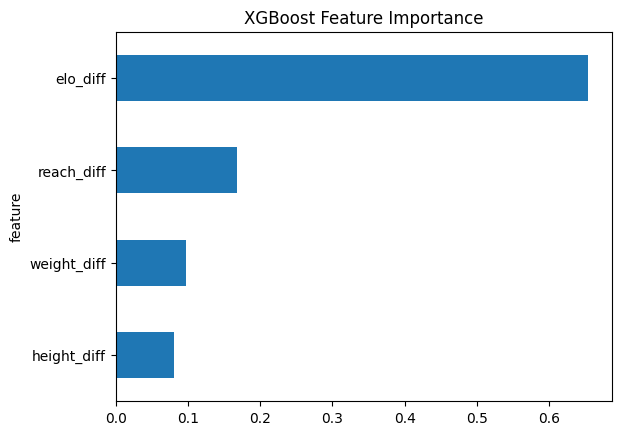

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

imp
imp.plot(kind="barh", x="feature", y="importance", legend=False)
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()



In [11]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

joblib.dump(model, "../models/xgb_fight_predictor.joblib")
joblib.dump(num_feats, "../models/model_features.joblib")

print("Saved model and feature list.")


Saved model and feature list.
